This notebook generates a population density map for Sweden, by municipality.

The GeoJSON for boundaries can be found here: https://github.com/okfse/sweden-geojson?tab=readme-ov-file

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("data/sweden_municipalities.geojson")
gdf.head()

Skipping field geo_point_2d: unsupported OGR type: 3


,lan_code,kom_namn,id,geometry
0,01,Tyresö,0138,"POLYGON ((18.46839 59.21953, 18.41824 59.2414,..."
1,01,Södertälje,0181,"POLYGON ((17.56827 59.29183, 17.51548 59.29527..."
2,03,Östhammar,0382,"POLYGON ((18.90585 60.27804, 18.87453 60.31068..."
3,04,Gnesta,0461,"POLYGON ((17.27697 59.16957, 17.22373 59.17604..."
4,08,Hultsfred,0860,"POLYGON ((16.209 57.48338, 16.17777 57.50456, ..."


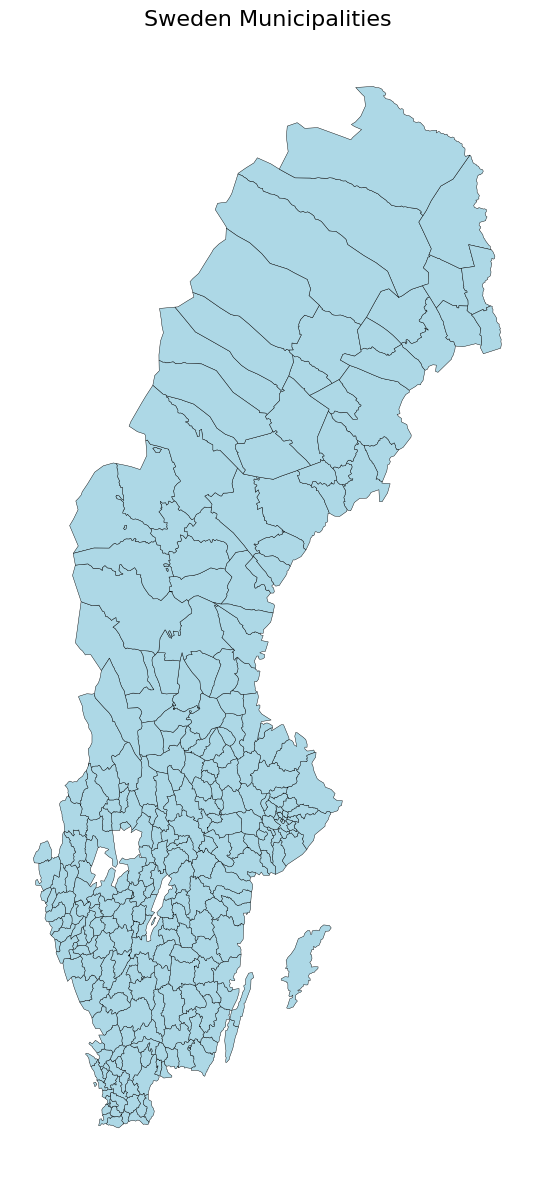

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(8, 12))
gdf.plot(ax=ax, edgecolor="black", linewidth=0.3, color="lightblue")
ax.set_title("Sweden Municipalities", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# List all municipalities in the GeoJSON
print(f"Total municipalities: {len(gdf)}\n")
for _, row in gdf.iterrows():
    print(f"{row['id']}  {row['kom_namn']}")

Total municipalities: 290

0138  Tyresö
0181  Södertälje
0382  Östhammar
0461  Gnesta
0860  Hultsfred
1490  Borås
2081  Borlänge
2421  Storuman
2582  Boden
0184  Solna
1486  Strömstad
1498  Tidaholm
1763  Forshaga
2085  Ludvika
2284  Örnsköldsvik
2523  Gällivare
0188  Norrtälje
0191  Sigtuna
0192  Nynäshamn
1383  Varberg
2309  Krokom
0162  Danderyd
0562  Finspång
0764  Alvesta
0765  Älmhult
1080  Karlskrona
1292  Ängelholm
1384  Kungsbacka
1496  Skövde
1760  Storfors
2062  Mora
0123  Järfälla
0480  Nyköping
0780  Växjö
0821  Högsby
1277  Åstorp
1427  Sotenäs
1461  Mellerud
1861  Hallsberg
2260  Ånge
2282  Kramfors
2513  Överkalix
2580  Luleå
0760  Uppvidinge
0861  Mönsterås
1231  Burlöv
1257  Örkelljunga
1489  Alingsås
1737  Torsby
1762  Munkfors
1907  Surahammar
2281  Sundsvall
2321  Åre
0187  Vaxholm
0509  Ödeshög
0561  Åtvidaberg
0662  Gislaved
1402  Partille
2305  Bräcke
2418  Malå
2521  Pajala
0128  Salem
1264  Skurup
1286  Ystad
1290  Kristianstad
1315  Hylte
1441  Lerum
1465  Sv

In [4]:
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

# Load population data
pop = pd.read_csv("data/sweden_population.csv", skiprows=1, encoding="latin-1")
pop.columns = ["sex", "month", "region", "population"]

# Extract municipality code from region (e.g. "0114 Upplands Väsby" → "0114")
pop["id"] = pop["region"].str[:4]

# Merge population into geodataframe
gdf2 = gdf.merge(pop[["id", "population"]], on="id", how="left")

# Compute area in km² (reproject to SWEREF99 TM for accurate area)
gdf2 = gdf2.to_crs(epsg=3006)
gdf2["area_km2"] = gdf2.geometry.area / 1e6

# Compute population density
gdf2["pop_density"] = gdf2["population"] / gdf2["area_km2"]

# Back to WGS84 for plotting
gdf2 = gdf2.to_crs(epsg=4326)

print(gdf2[["kom_namn", "population", "area_km2", "pop_density"]].sort_values("pop_density", ascending=False).head(15))

           kom_namn  population    area_km2  pop_density
239      Sundbyberg       57000    9.310449  6122.153601
261       Stockholm      999239  211.949008  4714.525495
9             Solna       86435   22.533069  3835.917790
147           Malmö      367924  177.271040  2075.488474
31         Järfälla       90180   63.374628  1422.966933
91       Sollentuna       78033   58.626897  1331.010231
201            Täby       78514   71.459093  1098.726513
45           Burlöv       20444   19.901806  1027.243464
115         Lidingö       48369   47.901176  1009.766433
21         Danderyd       32500   34.069900   953.921216
280           Nacka      113730  127.274923   893.577443
150        Göteborg      613278  719.749030   852.072006
166        Huddinge      114686  142.538919   804.594288
57         Partille       41164   61.417837   670.228745
103  Upplands Väsby       50495   86.808005   581.685983


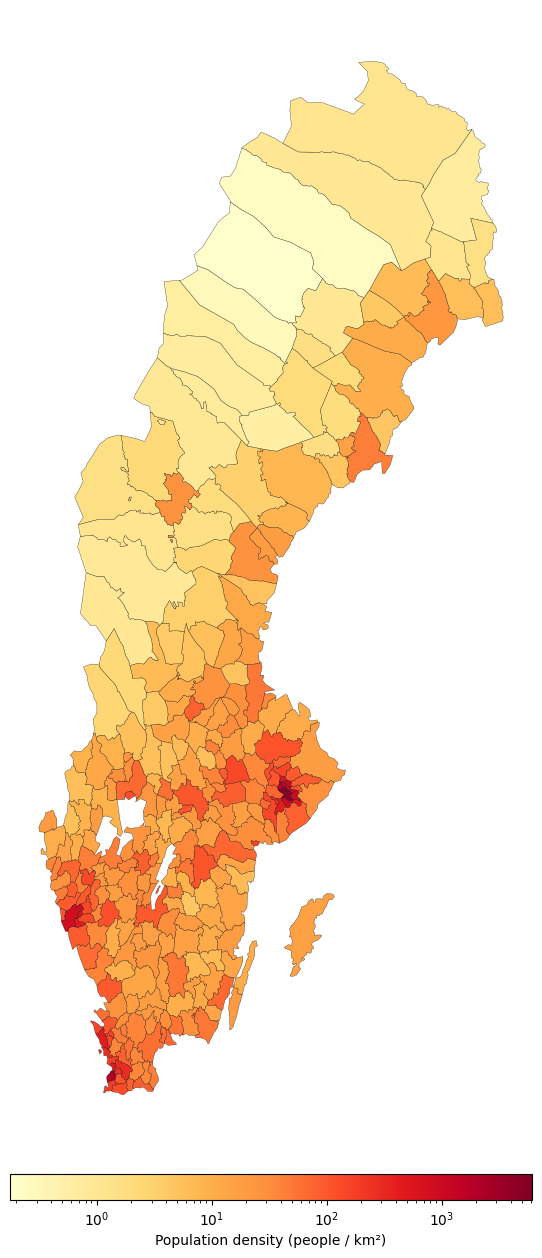

In [6]:
# Plot population density choropleth with log-scale color
fig, ax = plt.subplots(1, 1, figsize=(9, 14))

# Use a log norm to handle the huge range (rural ~1 vs Stockholm ~5000+)
vmin = gdf2["pop_density"].min()
vmax = gdf2["pop_density"].max()
norm = mcolors.LogNorm(vmin=max(vmin, 0.1), vmax=vmax)

gdf2.plot(
    column="pop_density",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Population density (people / km²)",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02,
    },
    cmap="YlOrRd",
    norm=norm,
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

ax.axis("off")
plt.tight_layout()
plt.show()